Link Google Colab: https://colab.research.google.com/drive/1i3s1Pe7RuEaP9_9nZPPbmRS3q6cR02Wm?usp=sharing

# Notebook ini melatih model Bidirectional LSTM untuk mendeteksi spoiler pada review buku Goodreads berbahasa Indonesia.

Input: `review_preprocessed.csv`  
Kolom yang dipakai: `review_text_clean`, `spoiler_label`  

## Mengapa Pendekatan Deep Learning?

Model ML klasik (SVM, RF, XGBoost) di notebook sebelumnya menggunakan TF-IDF, representasi teks yang menghitung frekuensi kata tanpa memperhatikan urutan. "Tidak mati" dan "mati tidak" menghasilkan representasi yang identik di TF-IDF.

LSTM (Long Short-Term Memory) adalah arsitektur jaringan saraf yang dirancang khusus untuk memproses data sekuensial. LSTM membaca teks kata per kata dan mempertahankan memori konteks dari kata-kata sebelumnya. Ini memungkinkan model memahami bahwa "ternyata dia yang membunuh" berbeda secara makna dari "dia yang membunuh ternyata", sesuatu yang tidak bisa ditangkap TF-IDF.

## Mengapa `review_text_clean` (bukan `review_text_stem`)?

LSTM belajar dari urutan dan konteks kata. Stemming mengubah "membunuh" menjadi "bunuh", yang memang berguna untuk TF-IDF tapi menghancurkan informasi morfologis yang bisa jadi sinyal penting bagi LSTM. Selain itu, pretrained FastText dilatih pada teks natural (belum di-stem), sehingga kosakatanya mencakup bentuk kata asli, bukan hasil stemming.

Catatan Perubahan dari Versi Sebelumnya

Ada empat perubahan di versi ini, semuanya berkaitan dengan dua masalah utama yang ditemukan:

1. Data leakage pada threshold tuning, sebelumnya threshold dicari di test set sehingga hasil evaluasi tidak valid
2. Overfitting parah, AUC validasi mentok di epoch pertama sementara AUC training terus naik mendekati 1.0

Perubahan yang dilakukan:
- Validation set dipisah secara stratified sebelum training
- Arsitektur model diperkecil dan regularisasi diperkuat
- Training dilakukan dalam dua fase (gradual unfreezing)
- Threshold tuning dipindahkan ke validation set

## Tahap-tahap
    
1. download & load FastText pretrained embedding

2. tokenisasi & padding sekuens

3. stratified train-val-test split (3 partisi)

4. build embedding matrix dari FastText

5. build arsitektur Bidirectional LSTM

6. training dua fase (embedding frozen -> unfreeze)

7. threshold tuning di validation set

8. evaluasi final di test set

9. plot training history

10. kesimpulan


## 1. Verifikasi GPU dan Instalasi Dependensi

Notebook ini dirancang untuk dijalankan di Google Colab dengan GPU T4

In [1]:
# verifikasi ketersediaan GPU
import subprocess
result = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
if result.returncode == 0:
  print("GPU tersedia")
  print(result.stdout[:500])
else:
  print("GPU tidak terdeteksi, pastikan runtime sudah diganti ke GPU T4")

GPU tersedia
Sun May 31 14:03:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|       


In [2]:
# install dependensi yang tidak tersedia default di Colab
# gensim : untuk load file FastText .vec (format teks)
!pip install -q gensim

## 1. Import Library & Konfigurasi

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import collections

from gensim.models import KeyedVectors

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
  Embedding, Bidirectional, LSTM, Dense,
  Dropout, SpatialDropout1D
)
from tensorflow.keras.callbacks import (
  EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2  # BARU: untuk regularisasi layer Dense

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
  classification_report,
  confusion_matrix,
  roc_auc_score,
  roc_curve,
  precision_score,
  recall_score,
  f1_score,
  ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# konfigurasi
INPUT_CSV = "review_preprocessed.csv"
FASTTEXT_PATH = "cc.id.300.vec"
MODEL_PATH = "best_lstm_model.keras"

RANDOM_SEED = 42
TEST_SIZE = 0.2
VAL_SIZE = 0.15   # BARU: ukuran validation set dari data train
MAXLEN = 1773   # p90 panjang review_text_clean
EMBED_DIM = 300
BATCH_SIZE = 64
MAX_EPOCHS = 30

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"TensorFlow versi: {tf.__version__}")
print(f"GPU tersedia: {len(tf.config.list_physical_devices('GPU'))} device")
print("import & konfigurasi selesai!")

TensorFlow versi: 2.20.0
GPU tersedia: 1 device
import & konfigurasi selesai!


## 2. Mount Google Drive & Load Data

In [4]:
from google.colab import drive
drive.mount("/content/drive")

DRIVE_BASE = "/content/drive/MyDrive/NLP_Kelompok3"
INPUT_CSV = os.path.join(DRIVE_BASE, "review_preprocessed.csv")
FASTTEXT_PATH = os.path.join(DRIVE_BASE, "cc.id.300.vec")
MODEL_PATH = os.path.join(DRIVE_BASE, "best_lstm_model.keras")

print(f"path dataset: {INPUT_CSV}")
print(f"path fasttext: {FASTTEXT_PATH}")
print(f"path model: {MODEL_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
path dataset: /content/drive/MyDrive/NLP_Kelompok3/review_preprocessed.csv
path fasttext: /content/drive/MyDrive/NLP_Kelompok3/cc.id.300.vec
path model: /content/drive/MyDrive/NLP_Kelompok3/best_lstm_model.keras


In [5]:
# load dataset
df = pd.read_csv(INPUT_CSV, encoding="utf-8-sig")

print(f"total baris: {len(df)}")
print(f"kolom: {list(df.columns)}")

print("\nmissing values pada kolom yang dipakai")
print(df[["review_text_clean", "spoiler_label"]].isnull().sum())

df = df.dropna(subset=["review_text_clean", "spoiler_label"]).reset_index(drop=True)
print(f"\nsetelah drop missing: {len(df)} baris")

total baris: 11267
kolom: ['review_text_clean', 'review_text_stem', 'spoiler_label']

missing values pada kolom yang dipakai
review_text_clean    0
spoiler_label        0
dtype: int64

setelah drop missing: 11267 baris


In [6]:
# distribusi label dan perhitungan imbalance
label_counts = df["spoiler_label"].value_counts()
n_nonspoiler = label_counts[0]
n_spoiler = label_counts[1]
imbalance_ratio = n_nonspoiler / n_spoiler

print("distribusi label")
print(pd.DataFrame({
  "jumlah" : label_counts,
  "persen" : (label_counts / len(df) * 100).round(2)
}).rename(index={0: "non-spoiler (0)", 1: "spoiler (1)"}))
print(f"\nimbalance ratio : {imbalance_ratio:.2f}")

# siapkan data
X = df["review_text_clean"].astype(str).tolist()
y = df["spoiler_label"].astype(int).values

distribusi label
                 jumlah  persen
spoiler_label                  
non-spoiler (0)   10281   91.25
spoiler (1)         986    8.75

imbalance ratio : 10.43


## 3. Download FastText Pretrained Embedding

### Mengapa FastText?

**FastText** dari Facebook Research adalah pretrained word embedding yang dilatih pada data Common Crawl + Wikipedia berbahasa Indonesia. FastText dipilih karena merupakan standar yang diakui untuk NLP bahasa Indonesia, dengan cakupan kosakata yang luas termasuk bahasa informal yang umum di review Goodreads.

FastText memiliki keunggulan tambahan: ia menggunakan **subword representation**, sehingga bisa menghasilkan embedding untuk kata yang belum pernah dilihat sebelumnya (*out-of-vocabulary*) dengan memanfaatkan karakter n-gram pembentuk kata tersebut.

### Format `.vec` vs `.bin`

Dipakai format `.vec` karena kompatibel langsung dengan Gensim tanpa dependensi tambahan. Kekurangannya: kata OOV tidak mendapat vektor (akan diisi nol).

In [7]:
# cek apakah file FastText sudah ada di Drive
if os.path.exists(FASTTEXT_PATH):
  print(f"file FastText sudah ada di: {FASTTEXT_PATH}")
  print("skip download!")
else:
  print("file FastText belum ada, mulai download...")
  print("ukuran file: ~4GB (format .vec.gz), estimasi waktu: 5-15 menit")

  !wget -q --show-progress \
      https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.id.300.vec.gz \
      -O /content/cc.id.300.vec.gz

  print("\nextrak file .gz...")
  !gunzip -f /content/cc.id.300.vec.gz

  print("salin ke Google Drive supaya tidak perlu download ulang")
  !cp /content/cc.id.300.vec {FASTTEXT_PATH}
  print(f"\nFastText tersimpan di Drive: {FASTTEXT_PATH}!")

file FastText sudah ada di: /content/drive/MyDrive/NLP_Kelompok3/cc.id.300.vec
skip download!


In [8]:
# load FastText embedding menggunakan Gensim
print("loading FastText embedding...")

fasttext_wv = KeyedVectors.load_word2vec_format(
  FASTTEXT_PATH,
  binary=False
)

print(f"\nFastText berhasil diload!")
print(f"jumlah kata dalam vocabulary FastText: {len(fasttext_wv.key_to_index):,}")
print(f"dimensi embedding: {fasttext_wv.vector_size}")

if "membunuh" in fasttext_wv:
  print(f"\ncek kata 'membunuh': ada di vocabulary!")
  print("5 kata paling mirip dengan 'membunuh':")
  for word, score in fasttext_wv.most_similar("membunuh", topn=5):
    print(f"{word}: {score:.4f}")

loading FastText embedding...

FastText berhasil diload!
jumlah kata dalam vocabulary FastText: 2,000,000
dimensi embedding: 300

cek kata 'membunuh': ada di vocabulary!
5 kata paling mirip dengan 'membunuh':
mebunuh: 0.7584
membunuh.: 0.7437
membunuhm: 0.7358
membunuhnya: 0.7352
membunuhya: 0.7347


## 4. Tokenisasi, Padding, dan Pembagian Data

Perubahan dari Versi Sebelumnya: Tiga Partisi

Di versi lama hanya ada train set dan test set. Di versi ini ditambahkan validation set yang terpisah secara stratified. Ada dua alasan:

1. Training yang lebih valid: `validation_split=0.15` di dalam `model.fit()` mengambil dari akhir array tanpa stratifikasi. Bisa saja 15% terakhir mayoritas berisi satu kelas tertentu secara kebetulan. Dengan split manual yang stratified, distribusi label di validation set terjamin sama dengan train set.

2. Threshold tuning yang valid: threshold optimal harus dicari di validation set, bukan test set. Kalau dicari di test set, kita sudah menggunakan informasi dari data uji untuk membuat keputusan model, ini data leakage.

Mengapa MAXLEN = 1773?

LSTM membutuhkan input dengan panjang yang sama. MAXLEN = 1773 adalah nilai persentil ke-90 dari panjang `review_text_clean`, artinya 90% review masuk penuh tanpa terpotong. 10% review yang lebih panjang akan dipotong dari kanan karena bagian akhir review umumnya berisi penutup, bukan informasi spoiler inti.

In [9]:
# verifikasi MAXLEN dari distribusi panjang teks
text_lengths = [len(text.split()) for text in X]
print("--- statistik panjang teks (jumlah token) ---")
for p in [50, 75, 90, 95, 99, 100]:
    print(f"  persentil {p:3d} : {np.percentile(text_lengths, p):.0f} token")

covered = sum(1 for l in text_lengths if l <= MAXLEN)
print(f"\nMAXLEN yang dipakai : {MAXLEN} (p90)")
print(f"review yang masuk penuh : {covered}/{len(X)} ({covered/len(X)*100:.1f}%)")

--- statistik panjang teks (jumlah token) ---
  persentil  50 : 69 token
  persentil  75 : 150 token
  persentil  90 : 266 token
  persentil  95 : 345 token
  persentil  99 : 587 token
  persentil 100 : 2115 token

MAXLEN yang dipakai : 1773 (p90)
review yang masuk penuh : 11264/11267 (100.0%)


In [10]:
# PERUBAHAN: stratified train-test split dilakukan sebelum tokenisasi
# supaya tokenizer di-fit hanya di train set (mencegah data leakage)
X_train_raw, X_test_raw, y_train_full, y_test = train_test_split(
  X, y,
  test_size=TEST_SIZE,
  random_state=RANDOM_SEED,
  stratify=y
)

# BARU: pisahkan validation set dari train set secara stratified
# sebelumnya validation_split=0.15 di dalam model.fit() tanpa stratifikasi
# masalah versi lama tidak ada jaminan distribusi label seimbang di val set
# solusinya split manual dengan stratify=y_train_full
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
  X_train_raw, y_train_full,
  test_size=VAL_SIZE,
  random_state=RANDOM_SEED,
  stratify=y_train_full
)

print(f"train set: {len(X_train_raw)} sampel")
print(f"val set: {len(X_val_raw)} sampel")
print(f"test set: {len(X_test_raw)} sampel")

# verifikasi proporsi label di ketiga partisi
print("\n proporsi spoiler per partisi")
for nama, y_part in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"  {nama:5s}: {y_part.mean():.4f}")

# hitung class_weight dari distribusi di train set
n_train      = len(y_train)
n_train_spl  = y_train.sum()
n_train_non  = n_train - n_train_spl
class_weight = {
  0: n_train / (2 * n_train_non),
  1: n_train / (2 * n_train_spl)
}
print(f"\n class_weight : {class_weight}")
print(f"artinya kesalahan pada spoiler dihukum {class_weight[1]/class_weight[0]:.1f}x lebih berat")

train set: 7661 sampel
val set: 1352 sampel
test set: 2254 sampel

 proporsi spoiler per partisi
  train: 0.0876
  val  : 0.0873
  test : 0.0874

 class_weight : {0: np.float64(0.5479971387696709), 1: np.float64(5.708643815201192)}
artinya kesalahan pada spoiler dihukum 10.4x lebih berat


In [11]:
# tokenisasi: fit hanya di train set
tokenizer = Tokenizer(oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_raw)

vocab_size = len(tokenizer.word_index) + 1
print(f"ukuran vocabulary (dari train set) : {vocab_size:,} kata")

# konversi teks ke sequence integer untuk ketiga partisi
X_train_seq = tokenizer.texts_to_sequences(X_train_raw)
X_val_seq   = tokenizer.texts_to_sequences(X_val_raw)
X_test_seq  = tokenizer.texts_to_sequences(X_test_raw)

# pad sequence ke panjang MAXLEN
X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=MAXLEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAXLEN, padding="post", truncating="post")

print(f"\nshape X_train_pad: {X_train_pad.shape}")
print(f"shape X_val_pad: {X_val_pad.shape}")
print(f"shape X_test_pad: {X_test_pad.shape}")

ukuran vocabulary (dari train set) : 30,523 kata

shape X_train_pad: (7661, 1773)
shape X_val_pad: (1352, 1773)
shape X_test_pad: (2254, 1773)


## 5. Build Embedding Matrix

Embedding matrix adalah matriks berukuran `(vocab_size, EMBED_DIM)` yang memetakan setiap indeks kata ke vektor 300 dimensi dari FastText. Matriks ini dimasukkan ke Embedding layer sebagai bobot awal yang akan diperbarui selama training.

In [12]:
# build embedding matrix
print(f"membangun embedding matrix ({vocab_size:,} x {EMBED_DIM})...")

embedding_matrix = np.zeros((vocab_size, EMBED_DIM))
word_index = tokenizer.word_index
oov_count = 0
found_count = 0

for word, idx in word_index.items():
  if idx >= vocab_size:
    continue
  if word in fasttext_wv:
    embedding_matrix[idx] = fasttext_wv[word]
    found_count += 1
  else:
    oov_count += 1

coverage = found_count / (found_count + oov_count) * 100
print(f"\nkata ditemukan di FastText: {found_count:,} ({coverage:.1f}%)")
print(f"kata OOV (tidak ditemukan): {oov_count:,} ({100-coverage:.1f}%)")
print(f"shape embedding matrix: {embedding_matrix.shape}")

# bebaskan memory FastText setelah embedding matrix selesai dibuat
# FastText menggunakan sekitar 5GB RAM, penting untuk dibebaskan sebelum training
del fasttext_wv
import gc
gc.collect()
print("\nmemory FastText dibebaskan!")

membangun embedding matrix (30,523 x 300)...

kata ditemukan di FastText: 25,606 (83.9%)
kata OOV (tidak ditemukan): 4,916 (16.1%)
shape embedding matrix: (30523, 300)

memory FastText dibebaskan!


## 6. Arsitektur Model: Bidirectional LSTM

**Perubahan Arsitektur dari Versi Sebelumnya**

Versi lama menggunakan model yang terlalu besar untuk ukuran data yang ada, sehingga overfitting terjadi sangat cepat (AUC validasi memuncak di epoch pertama). Perubahan yang dilakukan:

| Komponen | Versi Lama | Versi Baru | Alasan |
|---|---|---|---|
| LSTM units | 128 per arah (256 total) | 64 per arah (128 total) | kurangi kapasitas agar sesuai dengan jumlah data |
| Dropout setelah LSTM | 0.3 | 0.5 | regularisasi lebih kuat |
| Dense units | 64 | 32 | kurangi parameter |
| Dense regularizer | tidak ada | L2(0.01) | cegah overfitting di layer Dense |
| Dropout setelah Dense | 0.2 | 0.3 | regularisasi lebih kuat |
| Embedding trainable | True dari awal | False (fase 1), True (fase 2) | gradual unfreezing |

**Mengapa Bidirectional?**

Konteks spoiler sering bergantung pada kata setelahnya juga, bukan hanya sebelumnya. BiLSTM menangkap konteks dari kedua arah sekaligus.

**Mengapa Embedding Dimulai Frozen?**

Kalau embedding langsung trainable dari awal, gradient dari layer atas yang masih acak akan merusak bobot FastText yang sudah bagus. Dengan membekukan embedding di fase pertama, layer atas bisa stabil dulu sebelum embedding ikut di-update.

In [13]:
def build_bilstm_model(vocab_size, embed_dim, maxlen, embedding_matrix):
  """
  membangun arsitektur Bidirectional LSTM.
  embedding dimulai frozen untuk gradual unfreezing.
  """
  model = Sequential([
    # embedding layer
    # trainable=False di sini: embedding dibekukan di fase 1 training
    # nanti di fase 2 akan dibuka (model.layers[0].trainable = True)
    # PERUBAHAN: sebelumnya trainable=True langsung dari awal
    # alasan perubahan: gradient acak dari layer atas merusak bobot FastText
    Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        weights=[embedding_matrix],
        input_length=maxlen,
        trainable=False,   # PERUBAHAN: dimulai frozen
        mask_zero=True
    ),

    # spatial dropout pada embedding
    SpatialDropout1D(0.3),

    # PERUBAHAN: LSTM units dikecilkan dari 128 menjadi 64 per arah
    # alasan: 128 unit terlalu besar untuk ~600 sampel spoiler di train set
    # model berkapasitas besar langsung hafal data latih (overfitting)
    Bidirectional(LSTM(
        64,                  # PERUBAHAN: dari 128 jadi 64
        return_sequences=False
    )),

    # PERUBAHAN: Dropout dinaikkan dari 0.3 menjadi 0.5
    # alasan: regularisasi lebih kuat diperlukan untuk mencegah overfitting
    Dropout(0.5),            # PERUBAHAN: dari 0.3 jadi 0.5

    # PERUBAHAN: Dense dikecilkan dari 64 menjadi 32 unit
    # tambah L2 regularizer yang sebelumnya tidak ada
    # alasan: kurangi parameter total dan paksa bobot tetap kecil
    Dense(32, activation="relu",
          kernel_regularizer=l2(0.01)),   # PERUBAHAN: dari 64 tanpa regularizer

    # PERUBAHAN: Dropout dinaikkan dari 0.2 menjadi 0.3
    Dropout(0.3),            # PERUBAHAN: dari 0.2 jadi 0.3

    # output layer, sigmoid untuk klasifikasi biner
    Dense(1, activation="sigmoid")
  ])

  model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=["accuracy",
              tf.keras.metrics.AUC(name="auc"),
              tf.keras.metrics.Precision(name="precision"),
              tf.keras.metrics.Recall(name="recall")]
  )

  return model

# build model
model = build_bilstm_model(vocab_size, EMBED_DIM, MAXLEN, embedding_matrix)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     9,156,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,156,900 (34.93 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 9,156,900 (34.93 MB)

## 7. Training Model: Dua Fase

**Mengapa Dua Fase?**

Ini yang disebut gradual unfreezing, melatih model secara bertahap dari layer atas ke bawah.

**Fase 1** (embedding frozen): layer LSTM, Dense, dan output dilatih terlebih dahulu. Embedding tidak berubah. Ini memberi kesempatan layer atas untuk "stabil" sebelum ikut men-update embedding.

**Fase 2** (embedding dibuka): setelah layer atas cukup stabil, embedding dibuka dengan learning rate yang lebih kecil (1e-4 vs 1e-3) agar penyesuaian embedding berlangsung halus dan terkontrol, tidak merusak representasi awal dari FastText.

Untuk Handling Imbalance: `class_weight`

Keras `model.fit()` menerima parameter `class_weight`, dictionary yang memetakan indeks kelas ke bobot. Model mengalikan loss setiap sampel dengan bobot kelas-nya saat backpropagation, sehingga sampel spoiler mendapat penalti lebih besar saat salah diklasifikasikan.

Callbacks

- EarlyStopping: memantau `val_auc`. Jika tidak ada perbaikan selama 5 epoch, training dihentikan dan bobot terbaik dipulihkan.
- ModelCheckpoint: menyimpan model setiap kali AUC validasi membaik. Penting untuk Colab karena sesi bisa berakhir tiba-tiba.
- ReduceLROnPlateau: kurangi learning rate jika AUC validasi stagnan selama 3 epoch.

In [14]:
# definisikan callbacks
early_stopping = EarlyStopping(
  monitor="val_auc",
  patience=5,
  mode="max",
  restore_best_weights=True,
  verbose=1
)

model_checkpoint = ModelCheckpoint(
  filepath=MODEL_PATH,
  monitor="val_auc",
  save_best_only=True,
  mode="max",
  verbose=1
)

reduce_lr = ReduceLROnPlateau(
  monitor="val_auc",
  factor=0.5,
  patience=3,
  mode="max",
  min_lr=1e-6,
  verbose=1
)

callbacks = [early_stopping, model_checkpoint, reduce_lr]
print("callbacks siap!")

callbacks siap!


In [15]:
# FASE 1: embedding frozen, latih layer lain dulu
# PERUBAHAN: sebelumnya hanya ada satu fase training langsung dengan trainable=True
# alasan penambahan fase 1 supaya diberi kesempatan layer atas stabil sebelum embedding ikut diupdate, mencegah kerusakan bobot FastText di awal training

print("FASE 1: embedding frozen, melatih layer lain dulu (5 epoch)...")
print(f"class weight : {class_weight}")
print()

# PERUBAHAN: sekarang pakai validation_data eksplisit, bukan validation_split
# sebelumnya model.fit(..., validation_split=0.15)
# masalahnya validation_split tidak stratified, bisa menyebabkan evaluasi tidak stabil
history1 = model.fit(
  X_train_pad, y_train,
  epochs=5,
  batch_size=BATCH_SIZE,
  validation_data=(X_val_pad, y_val),   # PERUBAHAN: dari validation_split
  class_weight=class_weight,
  verbose=1
)

print(f"\nfase 1 selesai.")
print(f"val_auc akhir fase 1: {history1.history['val_auc'][-1]:.4f}")

FASE 1: embedding frozen, melatih layer lain dulu (5 epoch)...
class weight : {0: np.float64(0.5479971387696709), 1: np.float64(5.708643815201192)}

Epoch 1/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 16s 60ms/step - accuracy: 0.5952 - auc: 0.4937 - loss: 0.9388 - precision: 0.0853 - recall: 0.3726 - val_accuracy: 0.0910 - val_auc: 0.5254 - val_loss: 0.8139 - val_precision: 0.0876 - val_recall: 1.0000
Epoch 2/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - accuracy: 0.5149 - auc: 0.5461 - loss: 0.7276 - precision: 0.0941 - recall: 0.5261 - val_accuracy: 0.8380 - val_auc: 0.5468 - val_loss: 0.6894 - val_precision: 0.1367 - val_recall: 0.1610
Epoch 3/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.6494 - auc: 0.5532 - loss: 0.6982 - precision: 0.1044 - recall: 0.3964 - val_accuracy: 0.7330 - val_auc: 0.5537 - val_loss: 0.6872 - val_precision: 0.1167 - val_recall: 0.3136
Epoch 4/5
120/120 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - accuracy: 0.4941 - auc: 0.5481 - loss: 0.6956 - precision: 0.0969 - re

In [16]:
# FASE 2: buka embedding, fine-tune semua layer
# PERUBAHAN: sebelumnya tidak ada fase 2, training langsung selesai di fase 1

print("FASE 2: embedding di-unfreeze, fine-tuning semua layer...")

# buka embedding layer
model.layers[0].trainable = True

# compile ulang dengan learning rate yang lebih kecil
# learning rate dikecilkan dari 1e-3 menjadi 1e-4 supaya penyesuaian embedding
# berlangsung halus dan tidak merusak representasi awal dari FastText
model.compile(
  optimizer=Adam(learning_rate=1e-4),
  loss="binary_crossentropy",
  metrics=["accuracy",
            tf.keras.metrics.AUC(name="auc"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall")]
)

print(f"embedding sekarang trainable: {model.layers[0].trainable}")
print(f"learning rate baru: 1e-4 (lebih kecil dari fase 1: 1e-3)")
print()

history2 = model.fit(
  X_train_pad, y_train,
  epochs=MAX_EPOCHS,
  batch_size=BATCH_SIZE,
  validation_data=(X_val_pad, y_val),
  class_weight=class_weight,
  callbacks=callbacks,
  verbose=1
)

print(f"\nfase 2 selesai.")
print(f"training berhenti di epoch (fase 2): {len(history2.history['loss'])}")
print(f"val_auc terbaik fase 2: {max(history2.history['val_auc']):.4f}")

# gabungkan history fase 1 dan fase 2 untuk plotting
# BARU: sebelumnya hanya ada satu history
hist_combined = collections.defaultdict(list)
for k in history1.history:
  hist_combined[k] = history1.history[k] + history2.history[k]

FASE 2: embedding di-unfreeze, fine-tuning semua layer...
embedding sekarang trainable: True
learning rate baru: 1e-4 (lebih kecil dari fase 1: 1e-3)

Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.5934 - auc: 0.6217 - loss: 0.6699 - precision: 0.1210 - recall: 0.5943
Epoch 1: val_auc improved from None to 0.62418, saving model to /content/drive/MyDrive/NLP_Kelompok3/best_lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/NLP_Kelompok3/best_lstm_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - accuracy: 0.6546 - auc: 0.6116 - loss: 0.6766 - precision: 0.1281 - recall: 0.5067 - val_accuracy: 0.6516 - val_auc: 0.6242 - val_loss: 0.6950 - val_precision: 0.1300 - val_recall: 0.5254 - learning_rate: 1.0000e-04
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6938 - auc: 0.6737 - loss: 0.6510 - precision: 0.1537 - recall: 0.5722
Epoch 2: val_auc improved from 0.62418 to 0.65793, saving model to /content/drive/MyDrive/NLP_K

## 8. Threshold Tuning dan Evaluasi Final

### Perubahan Terpenting: Threshold Tuning Dipindahkan ke Validation Set

Di versi lama, threshold dicari dengan cara ini:

```python
# VERSI LAMA -> data leakage
y_prob = model.predict(X_test_pad).flatten()
for thresh in thresholds:
  y_pred = (y_prob >= thresh)
  f1 = f1_score(y_test, y_pred, ...) # pakai y_test untuk cari threshold
```

Masalahnya: kita menggunakan label dari test set untuk memilih threshold, sehingga threshold yang "optimal" ini sudah disesuaikan ke distribusi test set secara tidak sengaja. Hasil evaluasi di test set menjadi terlalu optimis dan tidak mencerminkan performa di data yang benar-benar baru.

Di versi baru, threshold dicari di **validation set**, lalu diterapkan ke test set tanpa menyentuh label test set sama sekali.

mencari threshold optimal di validation set...
threshold optimal (dari val set): 0.40
F1 spoiler di val set (threshold optimal): 0.3035
F1 spoiler di val set (threshold default): 0.2957

threshold 0.40 ini yang akan dipakai untuk evaluasi di test set


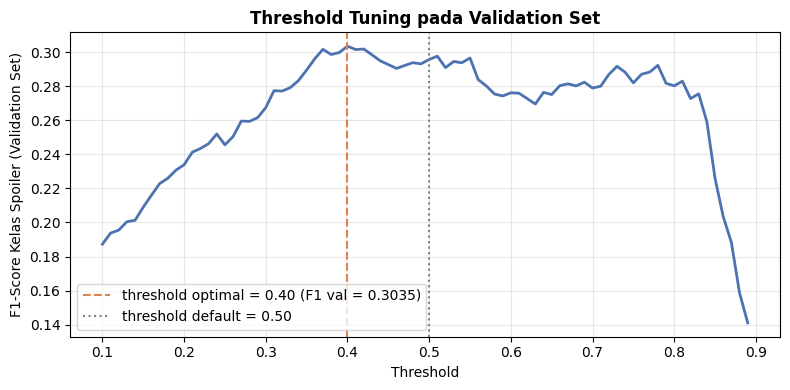

In [17]:
# PERUBAHAN: prediksi probabilitas di VALIDATION SET untuk mencari threshold optimal
# sebelumnya threshold dicari langsung di test set
print("mencari threshold optimal di validation set...")

y_val_prob = model.predict(X_val_pad, batch_size=BATCH_SIZE, verbose=0).flatten()

thresholds = np.arange(0.1, 0.9, 0.01)
f1_val_scores = []

for thresh in thresholds:
  y_pred_thresh = (y_val_prob >= thresh).astype(int)
  f1 = f1_score(y_val, y_pred_thresh, pos_label=1, zero_division=0)
  f1_val_scores.append(f1)

best_thresh_idx = np.argmax(f1_val_scores)
best_threshold = thresholds[best_thresh_idx]
best_f1_val = f1_val_scores[best_thresh_idx]

default_idx  = np.argmin(np.abs(thresholds - 0.5))
f1_default   = f1_val_scores[default_idx]

print(f"threshold optimal (dari val set): {best_threshold:.2f}")
print(f"F1 spoiler di val set (threshold optimal): {best_f1_val:.4f}")
print(f"F1 spoiler di val set (threshold default): {f1_default:.4f}")
print(f"\nthreshold {best_threshold:.2f} ini yang akan dipakai untuk evaluasi di test set")

# visualisasi threshold vs F1 spoiler (di validation set)
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_val_scores, color="#4C72B0", lw=2)
plt.axvline(x=best_threshold, color="#DD8452", linestyle="--",
            label=f"threshold optimal = {best_threshold:.2f} (F1 val = {best_f1_val:.4f})")
plt.axvline(x=0.5, color="gray", linestyle=":",
            label=f"threshold default = 0.50")
plt.xlabel("Threshold")
plt.ylabel("F1-Score Kelas Spoiler (Validation Set)")
plt.title("Threshold Tuning pada Validation Set", fontweight="bold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("threshold_tuning.png", dpi=150, bbox_inches="tight")
plt.show()

In [18]:
# evaluasi final di TEST SET menggunakan threshold yang ditemukan di val set
# test set baru disentuh di sini, setelah semua keputusan sudah dibuat
print("evaluasi final di test set...")

y_prob = model.predict(X_test_pad, batch_size=BATCH_SIZE, verbose=1).flatten()
y_pred_default = (y_prob >= 0.50).astype(int)
y_pred_optimal = (y_prob >= best_threshold).astype(int)

auc = roc_auc_score(y_test, y_prob)

print("EVALUASI DI TEST SET, THRESHOLD DEFAULT (0.50)")
print(classification_report(
  y_test, y_pred_default,
  target_names=["non-spoiler (0)", "spoiler (1)"],
  digits=4
))
print(f"AUC-ROC : {auc:.4f}")

print()
print(f"EVALUASI DI TEST SET, THRESHOLD OPTIMAL ({best_threshold:.2f})")
print(classification_report(
  y_test, y_pred_optimal,
  target_names=["non-spoiler (0)", "spoiler (1)"],
  digits=4
))
print(f"AUC-ROC: {auc:.4f} (AUC tidak bergantung threshold)")

evaluasi final di test set...
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
EVALUASI DI TEST SET, THRESHOLD DEFAULT (0.50)
                 precision    recall  f1-score   support

non-spoiler (0)     0.9362    0.8629    0.8981      2057
    spoiler (1)     0.2123    0.3858    0.2739       197

       accuracy                         0.8212      2254
      macro avg     0.5742    0.6243    0.5860      2254
   weighted avg     0.8729    0.8212    0.8435      2254

AUC-ROC : 0.6926

EVALUASI DI TEST SET, THRESHOLD OPTIMAL (0.40)
                 precision    recall  f1-score   support

non-spoiler (0)     0.9418    0.8182    0.8757      2057
    spoiler (1)     0.1991    0.4721    0.2801       197

       accuracy                         0.7879      2254
      macro avg     0.5705    0.6451    0.5779      2254
   weighted avg     0.8769    0.7879    0.8236      2254

AUC-ROC: 0.6926 (AUC tidak bergantung threshold)


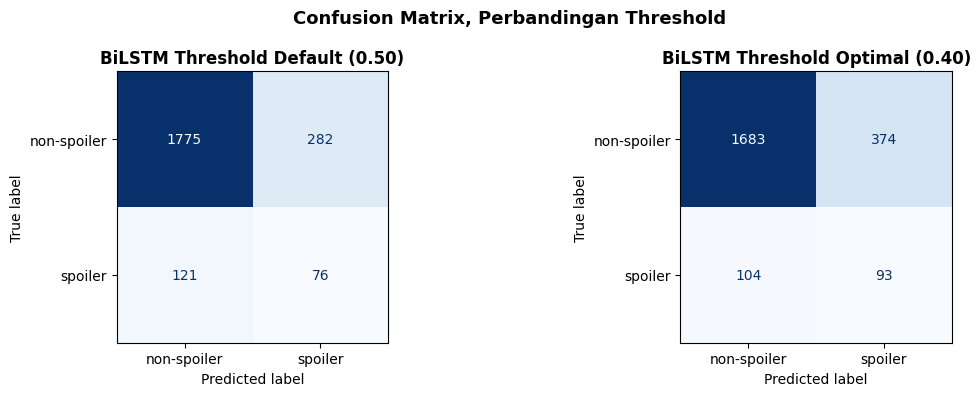

In [19]:
# confusion matrix, threshold default vs optimal
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (title, y_pred) in zip(axes, [
  ("Threshold Default (0.50)", y_pred_default),
  (f"Threshold Optimal ({best_threshold:.2f})", y_pred_optimal)
]):
  cm = confusion_matrix(y_test, y_pred)
  disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["non-spoiler", "spoiler"]
  )
  disp.plot(ax=ax, colorbar=False, cmap="Blues")
  ax.set_title(f"BiLSTM {title}", fontweight="bold")

plt.suptitle("Confusion Matrix, Perbandingan Threshold", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

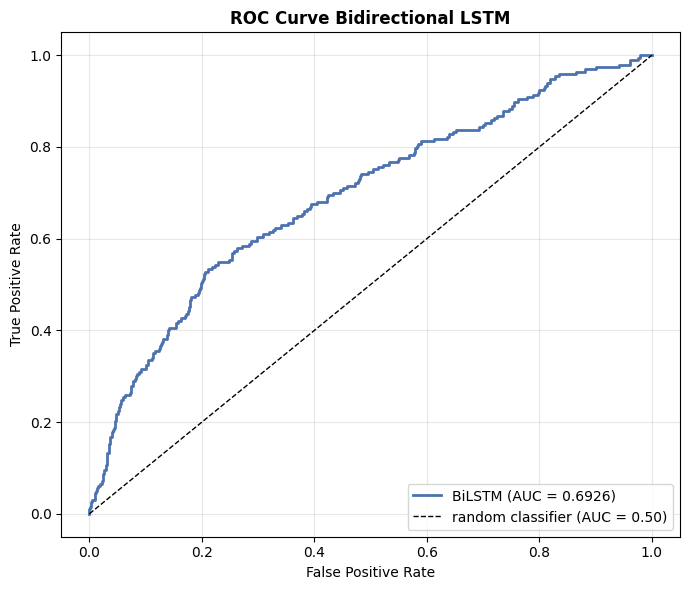

In [20]:
# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#4C72B0", lw=2, label=f"BiLSTM (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], "k--", lw=1, label="random classifier (AUC = 0.50)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Bidirectional LSTM", fontweight="bold")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve_lstm.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Analisis Training History

Plot training history memperlihatkan bagaimana metrik berkembang dari epoch ke epoch. Ini penting untuk mendeteksi:
- Overfitting: training loss terus turun tapi validation loss mulai naik
- Underfitting: kedua loss masih tinggi dan belum konvergen
- Good fit: keduanya turun dan konvergen pada nilai yang berdekatan

Garis vertikal putus-putus di plot menandai batas antara fase 1 (embedding frozen) dan fase 2 (embedding dibuka), sehingga pengaruh gradual unfreezing bisa terlihat secara visual.

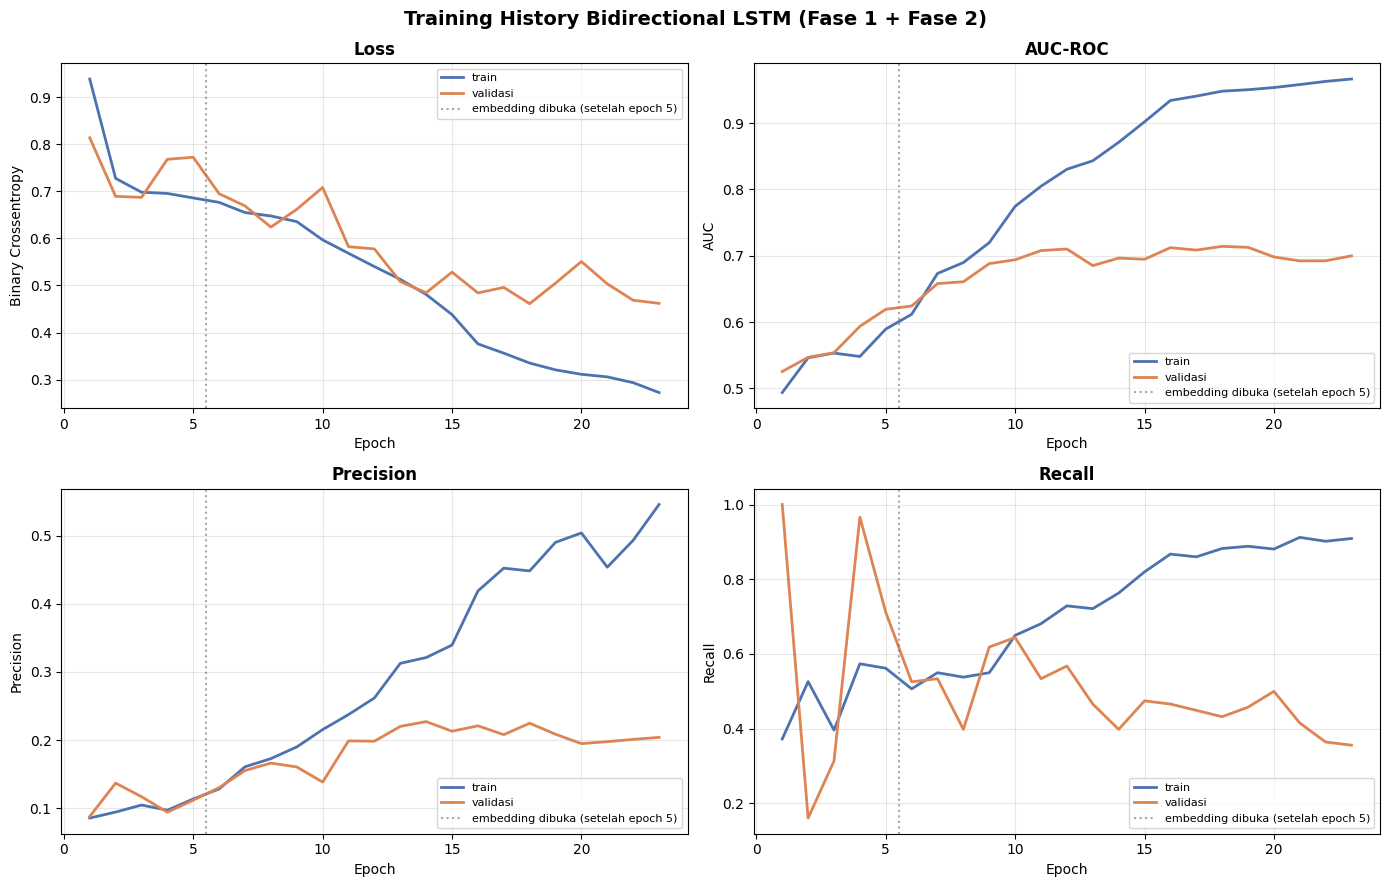

total epoch training: 23 (fase 1: 5, fase 2: 18)
val_auc terbaik (fase 2): 0.7141
epoch terbaik (fase 2): 18


In [21]:
# PERUBAHAN: sekarang pakai hist_combined yang menggabungkan fase 1 dan fase 2
# sebelumnya hanya pakai history.history dari satu fase training
hist = hist_combined
epochs_ran = range(1, len(hist["loss"]) + 1)
n_fase1 = len(history1.history["loss"]) # batas antara fase 1 dan fase 2

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (metric_train, metric_val, title, ylabel) in zip(
  axes.flatten(),
  [
    ("loss",      "val_loss",      "Loss",      "Binary Crossentropy"),
    ("auc",       "val_auc",       "AUC-ROC",   "AUC"),
    ("precision", "val_precision", "Precision", "Precision"),
    ("recall",    "val_recall",    "Recall",    "Recall"),
  ]
):
  ax.plot(epochs_ran, hist[metric_train], label="train",   color="#4C72B0", lw=2)
  ax.plot(epochs_ran, hist[metric_val],   label="validasi", color="#DD8452", lw=2)
  # garis pemisah fase 1 dan fase 2
  ax.axvline(x=n_fase1 + 0.5, color="gray", linestyle=":", alpha=0.7,
              label=f"embedding dibuka (setelah epoch {n_fase1})")
  ax.set_title(title, fontweight="bold")
  ax.set_xlabel("Epoch")
  ax.set_ylabel(ylabel)
  ax.legend(fontsize=8)
  ax.grid(alpha=0.3)

plt.suptitle("Training History Bidirectional LSTM (Fase 1 + Fase 2)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()

total_epochs = len(epochs_ran)
print(f"total epoch training: {total_epochs} (fase 1: {n_fase1}, fase 2: {total_epochs - n_fase1})")
print(f"val_auc terbaik (fase 2): {max(history2.history['val_auc']):.4f}")
print(f"epoch terbaik (fase 2): {np.argmax(history2.history['val_auc']) + 1 + n_fase1}")

## 10. Ringkasan Hasil

In [22]:
# ringkasan metrik final
print("RINGKASAN METRIK BIDIRECTIONAL LSTM")

for label, y_pred in [
  ("default (0.50)", y_pred_default),
  (f"optimal ({best_threshold:.2f})", y_pred_optimal)
]:
  print(f"\nthreshold {label}")
  print(f"AUC-ROC: {auc:.4f}")
  print(f"F1 macro: {f1_score(y_test, y_pred, average='macro', zero_division=0):.4f}")
  print(f"F1 spoiler: {f1_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"Presisi spoiler: {precision_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"Recall spoiler: {recall_score(y_test, y_pred, pos_label=1, zero_division=0):.4f}")
  print(f"F1 non-spoiler: {f1_score(y_test, y_pred, pos_label=0, zero_division=0):.4f}")

RINGKASAN METRIK BIDIRECTIONAL LSTM

threshold default (0.50)
AUC-ROC: 0.6926
F1 macro: 0.5860
F1 spoiler: 0.2739
Presisi spoiler: 0.2123
Recall spoiler: 0.3858
F1 non-spoiler: 0.8981

threshold optimal (0.40)
AUC-ROC: 0.6926
F1 macro: 0.5779
F1 spoiler: 0.2801
Presisi spoiler: 0.1991
Recall spoiler: 0.4721
F1 non-spoiler: 0.8757


## Catatan

**Pemilihan kolom `review_text_clean`**  
LSTM membutuhkan teks natural tanpa stemming karena belajar dari representasi kata asli yang tersedia di FastText. Stemming merusak informasi morfologis dan menyebabkan mismatch dengan vocabulary FastText.

**Gradual unfreezing embedding**  
Embedding FastText digunakan sebagai inisialisasi, bukan representasi tetap. Dimulai dari frozen supaya layer atas stabil dulu sebelum embedding ikut di-update dengan learning rate kecil di fase 2. Ini mencegah bobot FastText yang sudah bagus rusak oleh gradient acak di awal training.

**Handling imbalance dengan `class_weight`**  
Keras `class_weight` bekerja langsung pada fungsi loss tanpa mengubah distribusi data, lebih tepat untuk teks dibandingkan SMOTE yang melakukan interpolasi di ruang fitur.

**Threshold tuning di validation set**  
Threshold 0.5 adalah nilai default yang tidak selalu optimal pada data imbalanced. Threshold tuning dilakukan di validation set untuk menghindari data leakage. Test set hanya disentuh satu kali di akhir untuk evaluasi final.

**Keterbatasan**  
Dengan hanya sekitar 600 sampel spoiler di train set, model dengan kapasitas besar seperti BiLSTM tetap rentan overfitting meskipun sudah dikecilkan dan diberi regularisasi. Ini adalah batasan fundamental dari ukuran dataset yang ada.